In [37]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , mean_squared_error
import seaborn as sns 

In [38]:
import datetime as dt 
import warnings
warnings.filterwarnings('ignore')

# 1 EDA
# 1.1 Importing time series data



In [39]:
URL =  pd.read_csv("C:/Users/zakar/OneDrive/Desktop/Analyse_Predictive_du_trafic_aeroportuaire_a_l'aide_des_donnees_ouvertes/Air_Traffic_Passenger_Statistics.csv")
df = URL.copy()
df.head()

,Activity Period,operating_airline,operating_airline_iata,published_airline,published_airline_iata,geo_summary,geo_region,activity_type,price_category,terminal,boarding_area,passenger_count
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090


In [40]:


# info
print("data infos :",df.info())
print ("----------------------------------------")

# stats
print("describe : " ,df.describe())
print ("----------------------------------------")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22869 entries, 0 to 22868
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Activity Period         22869 non-null  int64 
 1   operating_airline       22869 non-null  object
 2   operating_airline_iata  22795 non-null  object
 3   published_airline       22869 non-null  object
 4   published_airline_iata  22795 non-null  object
 5   geo_summary             22869 non-null  object
 6   geo_region              22869 non-null  object
 7   activity_type           22869 non-null  object
 8   price_category          22869 non-null  object
 9   terminal                22869 non-null  object
 10  boarding_area           22869 non-null  object
 11  passenger_count         22869 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 2.1+ MB
data infos : None
----------------------------------------
describe :         Activity Period  passenger_count
c

Checking missing values 

In [41]:
nulls = df.isnull().sum().to_frame().sort_values(by=0,ascending=False)
nulls.columns = ['Missing values']
nulls[nulls['Missing values'] !=0]

,Missing values
operating_airline_iata,74
published_airline_iata,74


For better pre-processing, we will format the `Activity Period` to a *date type* and extract year component.

In [42]:
df.loc[:,'Activity Period']=pd.to_datetime(df.loc[:,'Activity Period'].astype(str), format='%Y%m')
df.loc[:,'Year'] = df['Activity Period'].dt.year
df.loc[:,'month']= df['Activity Period'].dt.month


In [43]:

df["Quarter"] = df["Activity Period"].dt.quarter
def season(x):
    if x in [12,1,2]:
        return "Winter"
    elif x in [3,4,5]:
        return "Spring"
    elif x in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["month"].apply(season)



Checking what time range is reported

In [44]:
time_begin  = df.loc[:,'Activity Period'].min()
time_end = df.loc[:,'Activity Period'].max()
time_range = time_end-time_begin
print('first date ', str(time_begin)[:11])
print('last date ', str(time_end)[:11])
print ('time range in day ', time_range.days)


first date  2005-07-01 
last date  2020-12-01 
time range in day  5632


# 1.2 Airline traffic generation

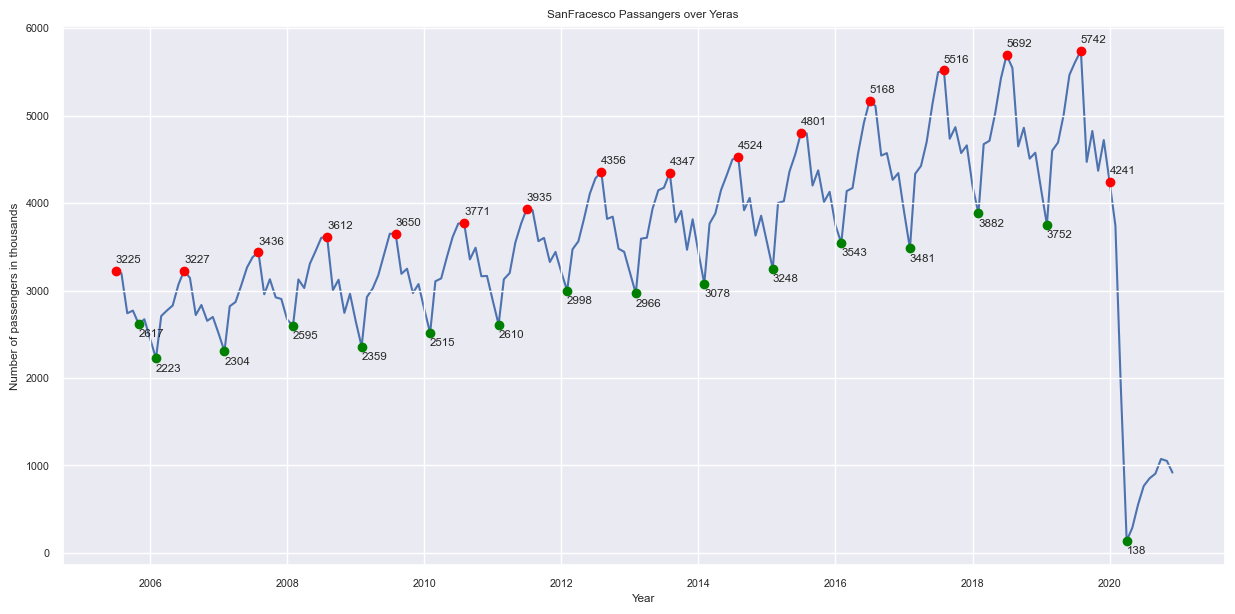

In [45]:
df_yr = df.groupby(["Activity Period"])["passenger_count"].sum().divide(1000)

fig, ax = plt.subplots(figsize=(15,7))

#Plotting the main PAX line
sns.lineplot(x=df_yr.index, y=df_yr.values, markers=True, ax=ax,zorder=0)

# Plotting vertical lines for beginning of each year 
#years = PAX_yr.index.year.unique()
#for year in years:
#    plt.axvline(x=year, ls = "--", c = "#3f5261", alpha=0.7)
    
# Looking for maximum PAX for each year
df_yr_maxs = df_yr.groupby(df_yr.index.year).max()
df_yr_max_complete = df_yr[df_yr.isin(df_yr_maxs.values)].to_frame()

# Marking points of interest
plt.scatter(df_yr_max_complete.index, df_yr_max_complete.values, color = "red", zorder=2)

#Annotating each marker
for t,v in df_yr_max_complete.reset_index().values:
    ax.text(t,v+90,int(v))
    
# Looking for minimum PAX for each year
df_yr_mins = df_yr.groupby(df_yr.index.year).min()
df_yr_min_complete = df_yr[df_yr.isin(df_yr_mins.values)].to_frame()
plt.scatter(df_yr_min_complete.index, df_yr_min_complete.values, color = "green", zorder=2)
for t,v in df_yr_min_complete.reset_index().values:
    ax.text(t,v-150,int(v))
    
plt.title("SanFracesco Passangers over Yeras ")
plt.xlabel("Year")
plt.ylabel("Number of passengers in thousands")
plt.grid(True)
plt.show()

The number of passengers is generally increasing (trend) with a clear seasonal pattern with a period of about one year. The traffic peak is around summertime while the lowest traffic is during wintertime at the beginning of the year.
The heatmap below shows what amount of traffic various airlines generated through the years (in thousands).

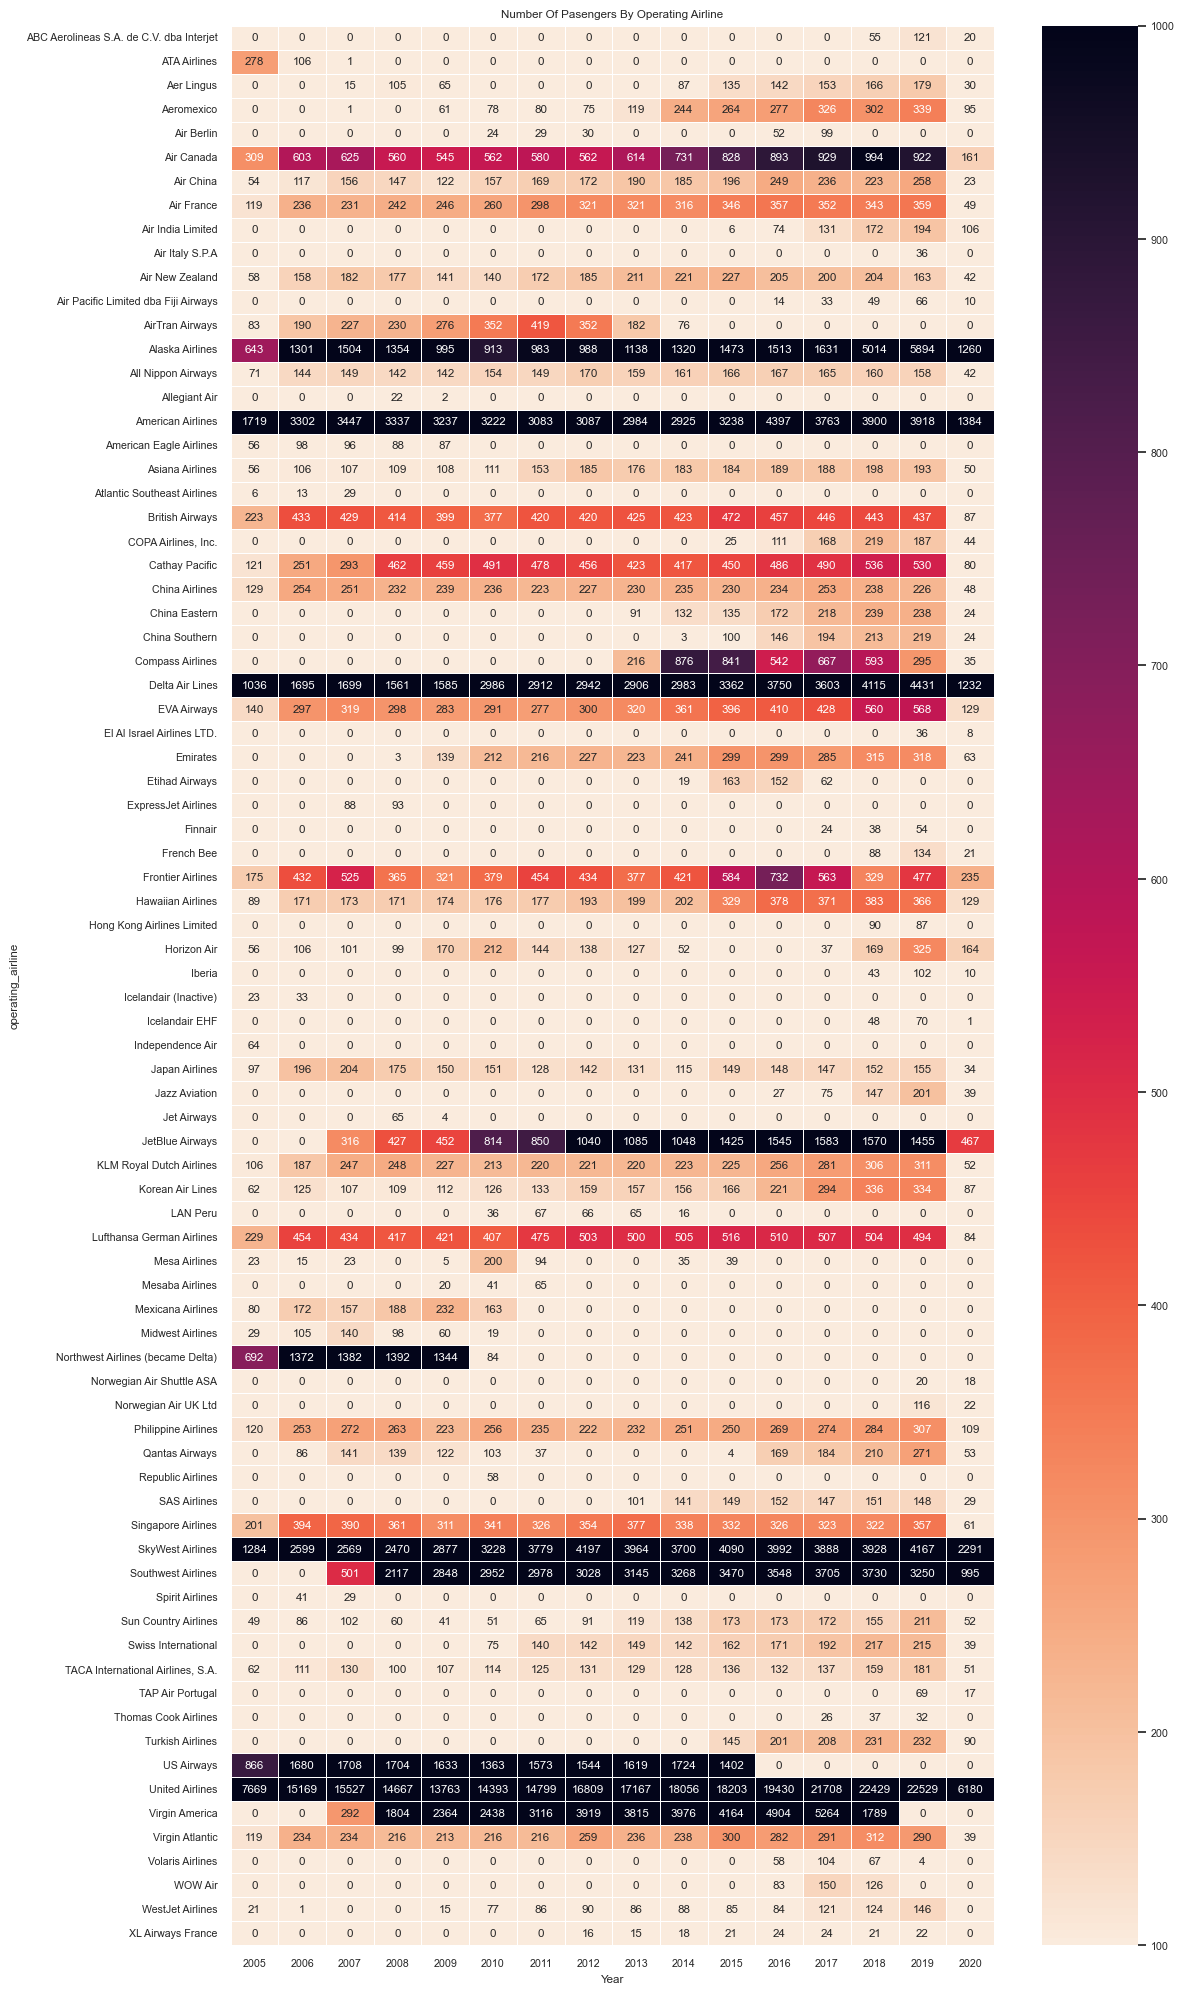

In [46]:
df_airline_yr = df.groupby(['Year','operating_airline'])['passenger_count'].sum().divide(1000)
df_airline_yr = df_airline_yr.reset_index()
pivot_1 = df_airline_yr.pivot_table(values='passenger_count',index='operating_airline', columns= 'Year', fill_value=0)
pivot_1.loc['United Airlines',:]=pivot_1.loc['United Airlines',:]+pivot_1.loc['United Airlines - Pre 07/01/2013',:]
pivot_1.drop('United Airlines - Pre 07/01/2013', axis = 0 , inplace = True )

# drop the small airlines 
smallest_airlines = pivot_1[pivot_1.sum(axis=1)<13]
pivot_1= pivot_1.drop(smallest_airlines.index,axis=0)

#plot 
sns.set(font_scale=0.7)
fig1= plt.figure(figsize=(12,20))
p1 = sns.heatmap(pivot_1, annot=True,linewidths=.5,vmin=100 , vmax = 1000,fmt='.0f', cmap=sns.cm.rocket_r)
p1.set_title("Number Of Pasengers By Operating Airline")
p1.set_yticklabels(p1.get_yticklabels(), rotation = 0)
plt.tight_layout()
plt.show()

It seams like we have a domination goes for some airlines (Alaska Airline , American Airline , Delta Airline , SkyWest Airline and United Airline )

now lets see the most airline with trafic , lets see who are the top 5 trought the years 

In [47]:
avg_airline = pivot_1.mean(axis=1)
top5_airline = avg_airline.nlargest(5).to_frame(name='Mean no. of passengers per year').mul(1000).astype('int64')
sum_of_all = top5_airline['Mean no. of passengers per year'].sum()
top5_airline['share [%]'] = top5_airline['Mean no. of passengers per year'].div(sum_of_all).mul(100).round(1)
top5_airline

,Mean no. of passengers per year,share [%]
operating_airline,,
United Airlines,16156044,58.1
SkyWest Airlines,3313883,11.9
American Airlines,3184016,11.5
Delta Air Lines,2674873,9.6
Southwest Airlines,2470935,8.9


# 1.3 TOP 5 BIGGEST AIRLINES

**1. United Airlines**

United is a huge American airline operating worldwide with strong presence in the Asia-Pacific region. It is founder of Star Alliance – international network of cooperating airlines. United has a fleet of over 760 airplanes of various types and employs over 88000 people. Its biggest hub is in Chicago O’Hare airport although San Francisco is its main West Coast hub.

**2. SkyWest Airlines**

SkyWest Airlines is an American airline operating on the regional North American market. Its flights are usually contracted by and operated under the name of other airlines. Its biggest clients are delta and United. SkyWest fleet consists mostly of regional jets (Bombardier CRJ series and Embraer 175) in number about 470. The airline ordered 100 brand new Embraer 175-E2 and 100 Mitsubishi MRJ90 jest to further expand its fleet.

**3. American Airlines**

American Airline (AA) is enormous American airline with headquarter in in Fort Worth, Texas. It has impressive fleet of over 950 airplanes and employs over 140 000 people. It is the founding member of Oneworld alliance. AA’s biggest hub is in Dallas/Fort Worth International Airport.

**4. Delta Airlines**

Delta Airlines is immense American airline with headquarters in Atlanta, Georgia. It is the founding member of SkyTeam airline alliance. Delta has a huge airplane fleet of 876 airplanes and employs over 86 000 people worldwide. Its main hub is in Atlanta International Airport. Historically, main milestones in term of Delta’s growth were two merges: with Western Airlines in 1987 and with Nortwest Airlines in 2009.

**5. Southwest Airlines**

Southwest airline was an American airline with headquarters in San Francisco operating until 2018 when it was merged with Alaska Airlines. Its business model was to operate low-fare services on the American West coast. The name was licences from UK-based Virgin Group which also controls brands of Virgin Atlantic and Virgin Australia. Its fleet consisted of 67 airplanes, mostly Airbus.


# 1.4 THE SMALLEST AIRLINES



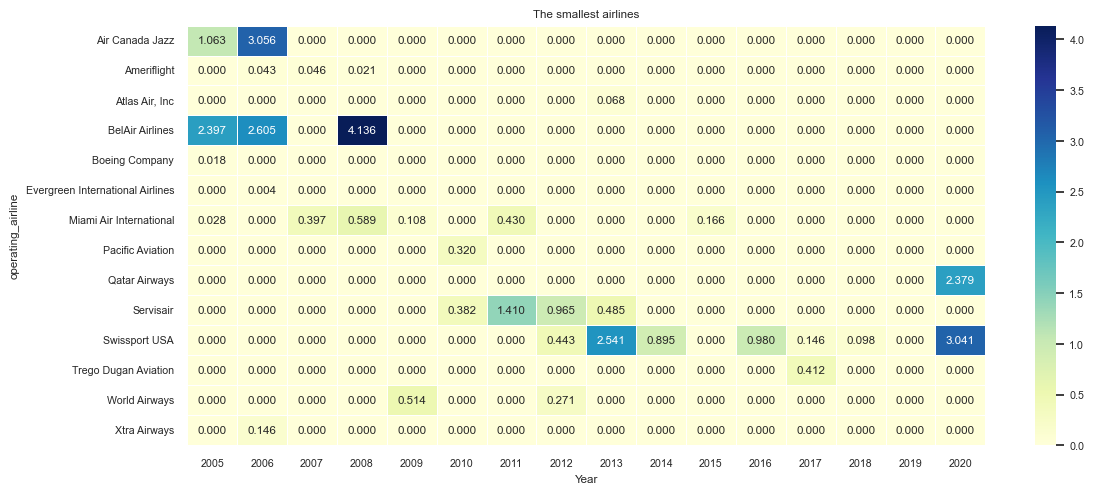

In [48]:
sns.set(font_scale=(0.7))

fig2 = plt.figure(figsize=(12,5))
p2 = sns.heatmap(smallest_airlines,annot = True , linewidths = .5,cmap='YlGnBu',fmt='.3f' )
p2.set_title('The smallest airlines')
p2.set_yticklabels(p2.get_yticklabels(), rotation= 0 )
plt.tight_layout()
plt.show()

# 1.5 Passanger traffic overview


<function matplotlib.pyplot.show(close=None, block=None)>

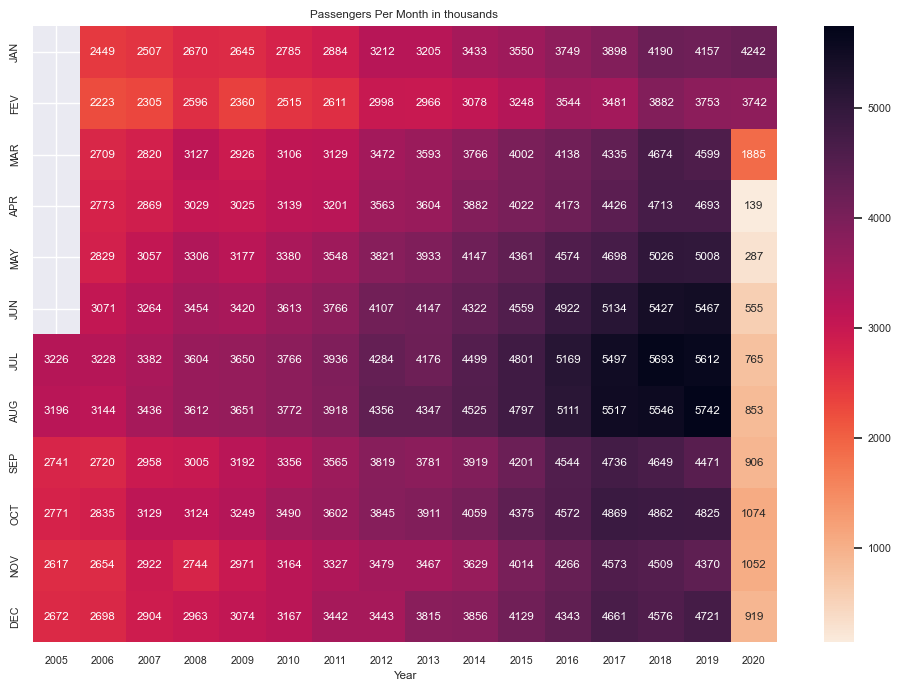

In [49]:
#group data 
df_yr_month = df.groupby(['month','Year'])['passenger_count'].sum()
#convert to thousands
df_yr_month = df_yr_month / 1000
# transform to table 
pivot = df_yr_month.unstack()
# rename month 
pivot.index = ['JAN','FEV','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
#plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(pivot,annot=True,fmt='.0f',cmap='rocket_r')
plt.title('Passengers Per Month in thousands ')
plt.show

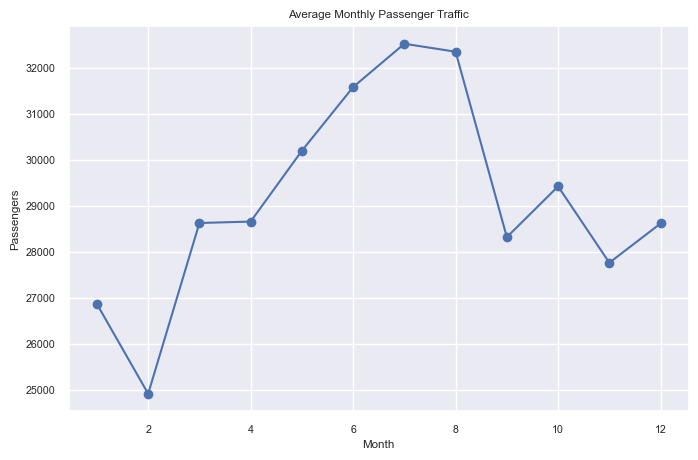

In [50]:
monthly_avg = df.groupby("month")["passenger_count"].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(marker='o')

plt.title("Average Monthly Passenger Traffic")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

# =========================
# 6. MACHINE LEARNING
# =========================


In [51]:
df.head(1)

,Activity Period,operating_airline,operating_airline_iata,published_airline,published_airline_iata,geo_summary,geo_region,activity_type,price_category,terminal,boarding_area,passenger_count,Year,month,Quarter,Season
0,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,2005,7,3,Summer


In [52]:
# copy data
df2 = df.copy()

In [53]:
# Convert date
df2["Activity Period"] = pd.to_datetime(df2["Activity Period"])
df2["Year"] = df2["Activity Period"].dt.year
df2["Month"] = df2["Activity Period"].dt.month

In [54]:
# Remove original date
df2.drop(columns=["Activity Period"], inplace=True)
df2.drop(columns=["Month"], inplace=True)


In [55]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
le = LabelEncoder()
for col in df2.select_dtypes(include="object").columns:
    df2[col] = le.fit_transform(df2[col].astype(str))



In [56]:
# Features / target
X = df2.drop(columns=["passenger_count"])
y = df2["passenger_count"]

In [57]:
# Train model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)


RandomForestRegressor(n_estimators=200, random_state=42)

In [58]:
# Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

terminal                  0.179745
activity_type             0.121008
Year                      0.115270
operating_airline         0.110804
operating_airline_iata    0.088655
geo_region                0.087133
boarding_area             0.083442
geo_summary               0.077935
price_category            0.055469
published_airline         0.026182
month                     0.024878
published_airline_iata    0.020572
Season                    0.004573
Quarter                   0.004334
dtype: float64


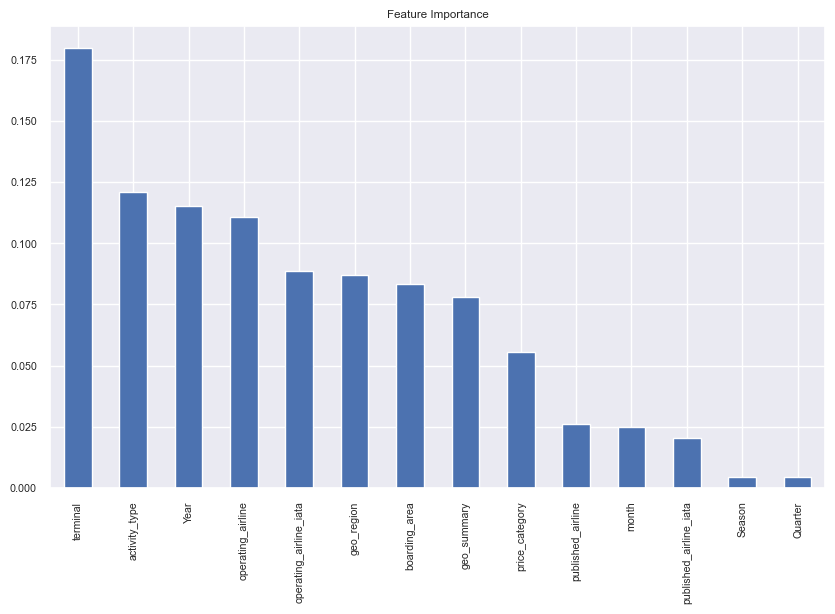

In [59]:
# Plot
plt.figure(figsize=(10,6))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

Feature importance analysis showed that terminal, activity type, year, and operating airline are the most influential variables in predicting passenger traffic.

In [85]:
# X , y 
X = df2[
[
"terminal",
"activity_type",
"Year",
"operating_airline",
"geo_region",
"boarding_area",
"geo_summary",
"price_category",
"month"
]]

y = df2["passenger_count"]

In [86]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2 , random_state=42) 

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
cat_cols = [
"terminal",
"activity_type",
"operating_airline",
"geo_region",
"boarding_area",
"geo_summary",
"price_category"
]

num_cols = ["Year", "month"]

preprocesor = ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols),
    ('num','passthrough',num_cols)
])

model = Pipeline([
    ('prep',preprocesor),
    ('rf',RandomForestRegressor(
        n_estimators= 200,
        random_state= 42))
])

In [89]:
#train model 
model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['terminal', 'activity_type',
                                                   'operating_airline',
                                                   'geo_region',
                                                   'boarding_area',
                                                   'geo_summary',
                                                   'price_category']),
                                                 ('num', 'passthrough',
                                                  ['Year', 'month'])])),
                ('rf',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [90]:
#predict model 
y_pred = model.predict(X_test)


In [91]:
y_pred_all = model.predict(df2[[
    "terminal", "activity_type", "Year", "operating_airline", 
    "geo_region", "boarding_area", "geo_summary", "price_category", "month"
]])
df2['passenger_predict'] = y_pred_all

In [92]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.011375509405567889
RMSE: 0.020743427477906064
R2 Score: 0.9321809911467775


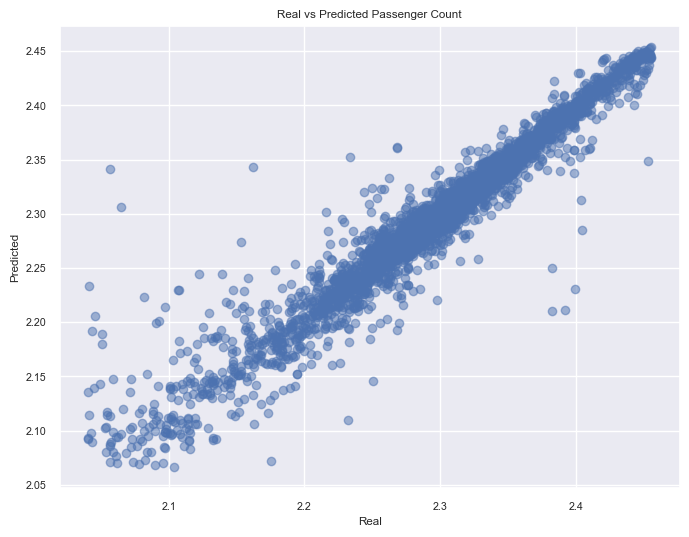

In [93]:
#reel vs predict
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Real vs Predicted Passenger Count")
plt.show()

<Axes: ylabel='passenger_count'>

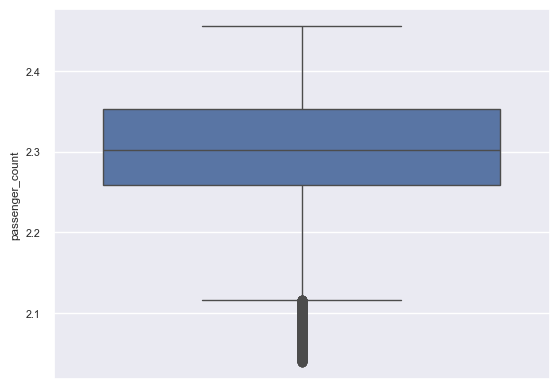

In [94]:
#Check outliers

sns.boxplot(y=y)

In [72]:
#remove outliers 
Q1 = df2['passenger_count'].quantile(0.25)
Q3 = df2['passenger_count'].quantile(0.75)
IQR = Q3 - Q1

df2 = df2[(df2['passenger_count'] >= Q1 - 1.5*IQR) & 
        (df2['passenger_count'] <= Q3 + 1.5*IQR)]

In [73]:
#make ann mormal distribution 
df2['passenger_count'] = np.log1p(df2['passenger_count'])

In [74]:
df.head()


,Activity Period,operating_airline,operating_airline_iata,published_airline,published_airline_iata,geo_summary,geo_region,activity_type,price_category,terminal,boarding_area,passenger_count,Year,month,Quarter,Season
0,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,2005,7,3,Summer
1,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,2005,7,3,Summer
2,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,2005,7,3,Summer
3,2005-07-01,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,2005,7,3,Summer
4,2005-07-01,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,2005,7,3,Summer


In [75]:
df2.head()


,operating_airline,operating_airline_iata,published_airline,published_airline_iata,geo_summary,geo_region,activity_type,price_category,terminal,boarding_area,passenger_count,Year,month,Quarter,Season,passenger_predict
0,1,73,1,67,0,8,0,0,2,1,2.417129,2005,7,3,2,25311.980
1,1,73,1,67,0,8,1,0,2,1,2.422995,2005,7,3,2,27524.195
2,1,73,1,67,0,8,2,0,2,1,2.261462,2005,7,3,2,5678.805
3,5,7,5,7,1,2,0,1,2,1,2.439524,2005,7,3,2,34887.655
4,5,7,5,7,1,2,1,1,2,1,2.436835,2005,7,3,2,34700.025


In [76]:
nulls2 = df2.isnull().sum().to_frame().sort_values(by=0,ascending=False)
nulls2.columns = ['Missing values']
nulls2[nulls2['Missing values'] !=0]

,Missing values


In [77]:
nulls


,Missing values
operating_airline_iata,74
published_airline_iata,74
operating_airline,0
Activity Period,0
published_airline,0
geo_summary,0
geo_region,0
activity_type,0
price_category,0
terminal,0


In [95]:
df2.to_csv("df2_clean.csv", index=False)